In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder,LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input
from tensorflow.keras.optimizers import Adam

In [2]:
df=pd.read_csv("train.csv")
df.head() #gives top 5 rows

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
df.tail() #gives last 5 rows

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


In [4]:
df.shape #614->rows 13->col

(614, 13)

In [5]:
df.info() #gives info about cols

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [6]:
df.isnull().sum() #gives no of missing values in each col

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [7]:
df.describe() # by default takes integer col

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


## Data Preprocessing

In [8]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [9]:
#handle numerical data(LoanAmount ,Loan_Amount_Term,Credit_History)
df['LoanAmount']=df['LoanAmount'].fillna(df['LoanAmount'].mean())
df['Loan_Amount_Term']=df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mean())
df['Credit_History']=df['Credit_History'].fillna(df['Credit_History'].mean())

In [10]:
#handle categorical data(Gender,Married,Dependents,Education)
df['Gender']=df['Gender'].fillna(df['Gender'].mode()[0])
df['Married']=df['Married'].fillna(df['Married'].mode()[0])
df['Dependents']=df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed']=df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

In [11]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


Exploratory Data Analysis(EDA)

<Axes: xlabel='count', ylabel='Gender'>

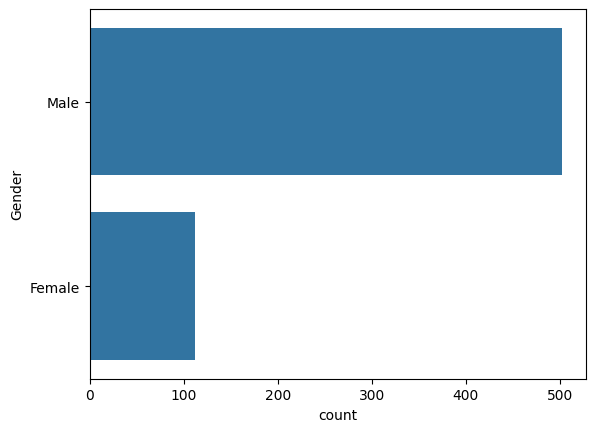

In [12]:
import seaborn as sns
sns.countplot(df['Gender'])

<Axes: xlabel='count', ylabel='Dependents'>

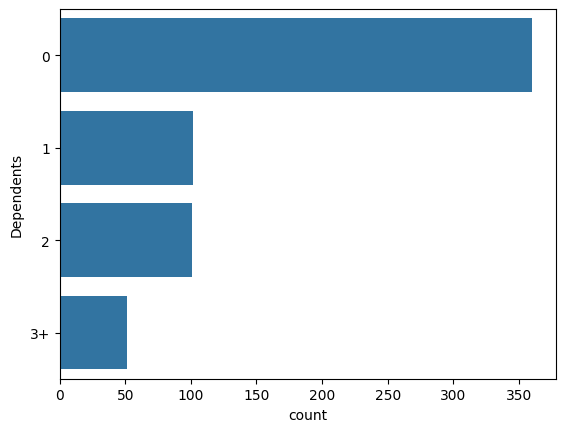

In [13]:
sns.countplot(df['Dependents'])

<Axes: xlabel='count', ylabel='Married'>

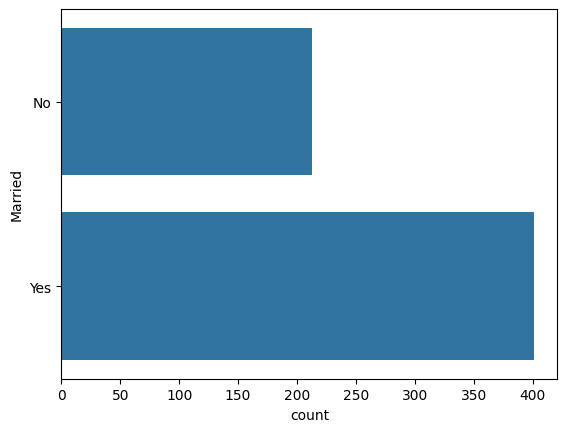

In [14]:
sns.countplot(df['Married'])

<ipython-input-15-67f12795949f>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.CoapplicantIncome) #coapplicant income is not normalized


<Axes: xlabel='CoapplicantIncome', ylabel='Density'>

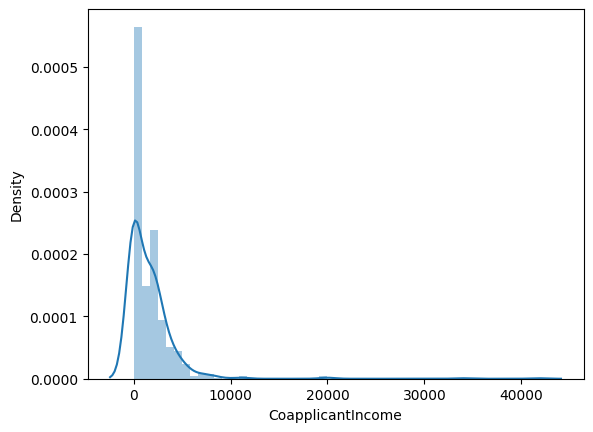

In [15]:
# numerical data
sns.distplot(df.CoapplicantIncome) #coapplicant income is not normalized

<ipython-input-16-f6ec9cb0ecfb>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.LoanAmount) # LoanAmount not normalized


<Axes: xlabel='LoanAmount', ylabel='Density'>

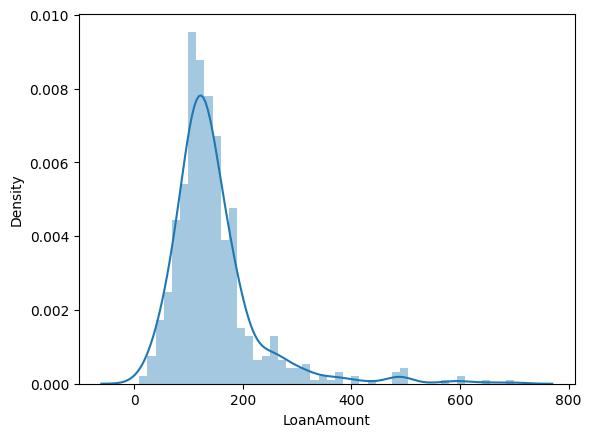

In [16]:
sns.distplot(df.LoanAmount) # LoanAmount not normalized

<ipython-input-17-4ce5cd7bbbe8>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.Credit_History) #Credit history not normalized


<Axes: xlabel='Credit_History', ylabel='Density'>

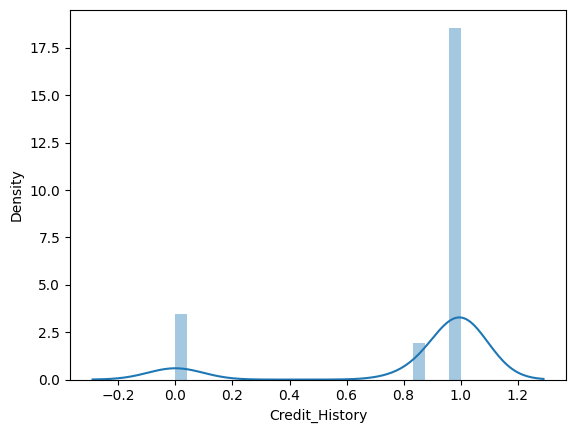

In [17]:
sns.distplot(df.Credit_History) #Credit history not normalized

In [18]:
#feature engineering
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']

In [19]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome
0,LP001002,Male,No,0,Graduate,No,5849,0.0,146.412162,360.0,1.0,Urban,Y,5849.0
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.000000,360.0,1.0,Rural,N,6091.0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.000000,360.0,1.0,Urban,Y,3000.0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.000000,360.0,1.0,Urban,Y,4941.0
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.000000,360.0,1.0,Urban,Y,6000.0


<ipython-input-20-0bbd95aa2a54>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.ApplicantIncomeLog) #Applicant Income has been normalized


<Axes: xlabel='ApplicantIncomeLog', ylabel='Density'>

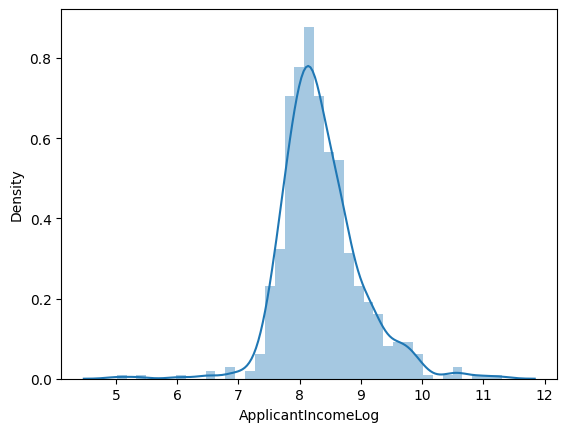

In [20]:
df['ApplicantIncomeLog']=np.log(df['ApplicantIncome'])
sns.distplot(df.ApplicantIncomeLog) #Applicant Income has been normalized

<ipython-input-21-0bbd95aa2a54>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.ApplicantIncomeLog) #Applicant Income has been normalized


<Axes: xlabel='ApplicantIncomeLog', ylabel='Density'>

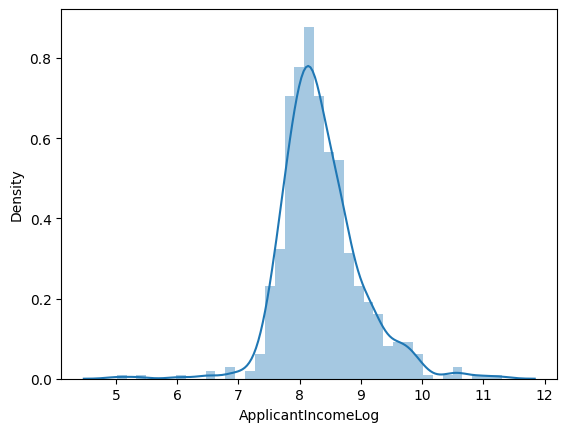

In [21]:
df['ApplicantIncomeLog']=np.log(df['ApplicantIncome'])
sns.distplot(df.ApplicantIncomeLog) #Applicant Income has been normalized

<ipython-input-22-b3ca7fc79d06>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.Loan_Amount_Term_Log) #Loan Amount Term has been normalized


<Axes: xlabel='Loan_Amount_Term_Log', ylabel='Density'>

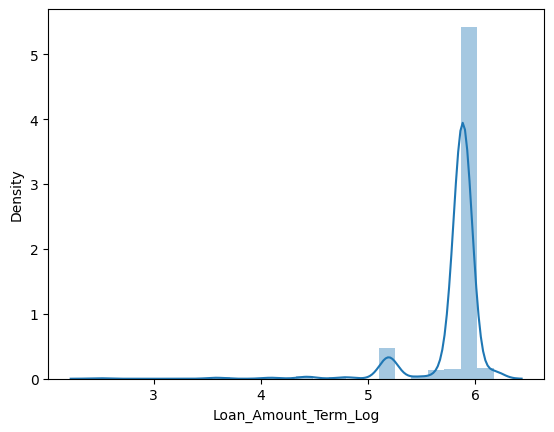

In [22]:
df['Loan_Amount_Term_Log']=np.log(df['Loan_Amount_Term'])
sns.distplot(df.Loan_Amount_Term_Log) #Loan Amount Term has been normalized

<ipython-input-23-ee833ab3d0c7>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Total_Income_Log"])  #Total income has been normalized


<Axes: xlabel='Total_Income_Log', ylabel='Density'>

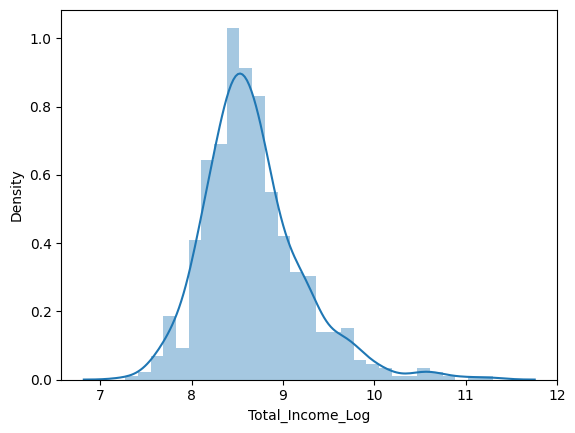

In [23]:
df['Total_Income_Log'] = np.log(df['TotalIncome'])
sns.distplot(df["Total_Income_Log"])  #Total income has been normalized

In [24]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,ApplicantIncomeLog,Loan_Amount_Term_Log,Total_Income_Log
0,LP001002,Male,No,0,Graduate,No,5849,0.0,146.412162,360.0,1.0,Urban,Y,5849.0,8.674026,5.886104,8.674026
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.000000,360.0,1.0,Rural,N,6091.0,8.430109,5.886104,8.714568
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.000000,360.0,1.0,Urban,Y,3000.0,8.006368,5.886104,8.006368
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.000000,360.0,1.0,Urban,Y,4941.0,7.856707,5.886104,8.505323
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.000000,360.0,1.0,Urban,Y,6000.0,8.699515,5.886104,8.699515


/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
<ipython-input-25-8d5002b77624>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Total_Income_Log"])


<Axes: xlabel='Total_Income_Log', ylabel='Density'>

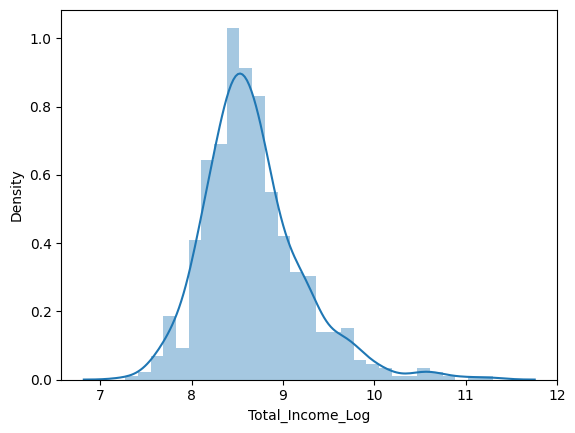

In [25]:
df['CoapplicantIncomeLog'] = np.log(df['CoapplicantIncome'])
sns.distplot(df["Total_Income_Log"])

In [26]:
cols = ['ApplicantIncome', 'CoapplicantIncome', "LoanAmount", "Loan_Amount_Term", "TotalIncome", 'Loan_ID', 'CoapplicantIncomeLog']
df = df.drop(columns=cols, axis=1)

In [27]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,Credit_History,Property_Area,Loan_Status,ApplicantIncomeLog,Loan_Amount_Term_Log,Total_Income_Log
0,Male,No,0,Graduate,No,1.0,Urban,Y,8.674026,5.886104,8.674026
1,Male,Yes,1,Graduate,No,1.0,Rural,N,8.430109,5.886104,8.714568
2,Male,Yes,0,Graduate,Yes,1.0,Urban,Y,8.006368,5.886104,8.006368
3,Male,Yes,0,Not Graduate,No,1.0,Urban,Y,7.856707,5.886104,8.505323
4,Male,No,0,Graduate,No,1.0,Urban,Y,8.699515,5.886104,8.699515


In [28]:
df.Gender.value_counts()

,count
Gender,
Male,502
Female,112


In [29]:
df.Education.value_counts()

,count
Education,
Graduate,480
Not Graduate,134


In [30]:
#convert categorical data to numerical data using one hot encoding
d1 = pd.get_dummies(df['Gender'], drop_first= True)
d2 = pd.get_dummies(df['Married'], drop_first= True)
d3 = pd.get_dummies(df['Dependents'], drop_first= True)
d4 = pd.get_dummies(df['Education'], drop_first= True)
d5 = pd.get_dummies(df['Self_Employed'], drop_first= True)
d6 = pd.get_dummies(df['Property_Area'], drop_first= True)



df1 = pd.concat([df, d1, d2, d3, d4, d5, d6], axis = 1)
df=df1

cols = ['Gender', 'Married', "Dependents", "Education", "Self_Employed", 'Property_Area']
df = df.drop(columns=cols, axis=1)

In [31]:
df.head()

,Credit_History,Loan_Status,ApplicantIncomeLog,Loan_Amount_Term_Log,Total_Income_Log,Male,Yes,1,2,3+,Not Graduate,Yes,Semiurban,Urban
0,1.0,Y,8.674026,5.886104,8.674026,True,False,False,False,False,False,False,False,True
1,1.0,N,8.430109,5.886104,8.714568,True,True,True,False,False,False,False,False,False
2,1.0,Y,8.006368,5.886104,8.006368,True,True,False,False,False,False,True,False,True
3,1.0,Y,7.856707,5.886104,8.505323,True,True,False,False,False,True,False,False,True
4,1.0,Y,8.699515,5.886104,8.699515,True,False,False,False,False,False,False,False,True


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Credit_History        614 non-null    float64
 1   Loan_Status           614 non-null    object 
 2   ApplicantIncomeLog    614 non-null    float64
 3   Loan_Amount_Term_Log  614 non-null    float64
 4   Total_Income_Log      614 non-null    float64
 5   Male                  614 non-null    bool   
 6   Yes                   614 non-null    bool   
 7   1                     614 non-null    bool   
 8   2                     614 non-null    bool   
 9   3+                    614 non-null    bool   
 10  Not Graduate          614 non-null    bool   
 11  Yes                   614 non-null    bool   
 12  Semiurban             614 non-null    bool   
 13  Urban                 614 non-null    bool   
dtypes: bool(9), float64(4), object(1)
memory usage: 29.5+ KB


In [33]:
test = pd.read_csv("test.csv")
# filling numerical missing data
test['LoanAmount']=test['LoanAmount'].fillna(test['LoanAmount'].mean())
test['Loan_Amount_Term']=test['Loan_Amount_Term'].fillna(test['Loan_Amount_Term'].mean())
test['Credit_History']=test['Credit_History'].fillna(test['Credit_History'].mean())

# filling categorical missing data
test['Gender']=test['Gender'].fillna(test['Gender'].mode()[0])
test['Married']=test['Married'].fillna(test['Married'].mode()[0])
test['Dependents']=test['Dependents'].fillna(test['Dependents'].mode()[0])
test['Self_Employed']=test['Self_Employed'].fillna(test['Self_Employed'].mode()[0])

test['Total_income'] = test['ApplicantIncome']+test['CoapplicantIncome']

# apply log transformation to the attribute
test['ApplicantIncomeLog'] = np.log(test['ApplicantIncome']+1)

test['CoapplicantIncomeLog'] = np.log(test['CoapplicantIncome']+1)

test['LoanAmountLog'] = np.log(test['LoanAmount'])

test['Loan_Amount_Term_Log'] = np.log(test['Loan_Amount_Term'])

test['Total_Income_Log'] = np.log(test['Total_income'])

cols = ['ApplicantIncome', 'CoapplicantIncome', "LoanAmount", "Loan_Amount_Term", "Total_income", 'Loan_ID', 'CoapplicantIncomeLog']
test = test.drop(columns=cols, axis=1)

t1 = pd.get_dummies(test['Gender'], drop_first= True)
t2 = pd.get_dummies(test['Married'], drop_first= True)
t3 = pd.get_dummies(test['Dependents'], drop_first= True)
t4 = pd.get_dummies(test['Education'], drop_first= True)
t5 = pd.get_dummies(test['Self_Employed'], drop_first= True)
t6 = pd.get_dummies(test['Property_Area'], drop_first= True)



df1 = pd.concat([test, t1, t2, t3, t4, t5, t6], axis = 1)
test=df1

cols = ['Gender', 'Married', "Dependents", "Education", "Self_Employed", 'Property_Area']
test = test.drop(columns=cols, axis=1)

In [34]:
df.describe()

,Credit_History,ApplicantIncomeLog,Loan_Amount_Term_Log,Total_Income_Log
count,614.000000,614.000000,614.000000,614.000000
mean,0.842199,8.341213,5.802065,8.669414
std,0.349681,0.645263,0.312482,0.545102
min,0.000000,5.010635,2.484907,7.273786
25%,1.000000,7.964677,5.886104,8.334712
50%,1.000000,8.246040,5.886104,8.597205
75%,1.000000,8.664750,5.886104,8.925549
max,1.000000,11.302204,6.173786,11.302204


### train test split

In [35]:
df.head()

,Credit_History,Loan_Status,ApplicantIncomeLog,Loan_Amount_Term_Log,Total_Income_Log,Male,Yes,1,2,3+,Not Graduate,Yes,Semiurban,Urban
0,1.0,Y,8.674026,5.886104,8.674026,True,False,False,False,False,False,False,False,True
1,1.0,N,8.430109,5.886104,8.714568,True,True,True,False,False,False,False,False,False
2,1.0,Y,8.006368,5.886104,8.006368,True,True,False,False,False,False,True,False,True
3,1.0,Y,7.856707,5.886104,8.505323,True,True,False,False,False,True,False,False,True
4,1.0,Y,8.699515,5.886104,8.699515,True,False,False,False,False,False,False,False,True


In [36]:
# specify input and output attributes
x = df.drop(columns=['Loan_Status'], axis=1)
y = df['Loan_Status']

In [37]:
# Split the dataset
from sklearn.model_selection import train_test_split
# Split data into train & test sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

# Normalize the features
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

Random Forest Classifier

In [38]:
# randomforest classifier
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf.fit(x_train, y_train)
y_pred = rf.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7662337662337663


Decision Tree Classifier

In [40]:
from sklearn.tree import DecisionTreeClassifier
dt= DecisionTreeClassifier(random_state=42)
dt.fit(x_train, y_train)
y_pred = dt.predict(x_test)

In [39]:
report = classification_report(y_test, y_pred, target_names=['Rejected', 'Approved'])
print("Classification Report:\n", report)

Classification Report:
               precision    recall  f1-score   support

    Rejected       0.80      0.44      0.57        54
    Approved       0.76      0.94      0.84       100

    accuracy                           0.77       154
   macro avg       0.78      0.69      0.71       154
weighted avg       0.77      0.77      0.75       154



In [41]:
# Evaluate the model
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Decision Tree Accuracy: 0.7272727272727273
Classification Report:
               precision    recall  f1-score   support

           N       0.64      0.52      0.57        54
           Y       0.76      0.84      0.80       100

    accuracy                           0.73       154
   macro avg       0.70      0.68      0.69       154
weighted avg       0.72      0.73      0.72       154



Logistic Regression

In [42]:
# import libraries
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
# fit the model
model = LogisticRegression()
model.fit(x_train, y_train)
log_reg = LogisticRegression()
log_reg.fit(x_train, y_train)
y_pred_log = log_reg.predict(x_test)

In [43]:
 # Evaluate the Logistic Regression model
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("Classification Report:\n", classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.7727272727272727
Classification Report:
               precision    recall  f1-score   support

           N       0.91      0.39      0.55        54
           Y       0.75      0.98      0.85       100

    accuracy                           0.77       154
   macro avg       0.83      0.68      0.70       154
weighted avg       0.81      0.77      0.74       154



In [53]:
#  Ensure x_train is a DataFrame for proper preprocessing
if not isinstance(x_train, pd.DataFrame):
    x_train = pd.DataFrame(x_train)
    x_test = pd.DataFrame(x_test)

#  Handle missing values (Fill NaNs with median)
x_train.fillna(x_train.median(), inplace=True)
x_test.fillna(x_test.median(), inplace=True)

# Convert categorical features to numeric using one-hot encoding
x_train = pd.get_dummies(x_train)
x_test = pd.get_dummies(x_test)

# Ensure test and train sets have same feature columns
x_test = x_test.reindex(columns=x_train.columns, fill_value=0)

In [54]:
# Normalize features
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# Ensure target variable is numeric
if y_train.dtype == 'object':
    label_encoder = LabelEncoder()
    y_train = label_encoder.fit_transform(y_train)
    y_test = label_encoder.transform(y_test)

# Convert to NumPy arrays
x_train, x_test = np.array(x_train, dtype=np.float32), np.array(x_test, dtype=np.float32)
y_train, y_test = np.array(y_train, dtype=np.float32), np.array(y_test, dtype=np.float32)


Neural Network

In [55]:
# Build Neural Network Model
model = Sequential([
    Dense(32, activation='relu', input_shape=(x_train.shape[1],)),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # Binary classification
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [56]:
# Compile Model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [57]:
# Train Model
history = model.fit(x_train, y_train, epochs=50, batch_size=16, validation_data=(x_test, y_test))

Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5382 - loss: 0.7184 - val_accuracy: 0.5974 - val_loss: 0.7060
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6409 - loss: 0.6673 - val_accuracy: 0.6429 - val_loss: 0.6784
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6844 - loss: 0.6618 - val_accuracy: 0.6494 - val_loss: 0.6567
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7063 - loss: 0.6150 - val_accuracy: 0.6818 - val_loss: 0.6370
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7747 - loss: 0.5539 - val_accuracy: 0.7208 - val_loss: 0.6159
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7634 - loss: 0.5403 - val_accuracy: 0.7597 - val_loss: 0.5979
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7845 - loss: 0.5503 - val_accuracy: 0.7727 - val_loss: 0.5836
Epoch 8/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7761 - loss: 0.5274 - val_accuracy: 0.7727 - val_los

In [58]:
# Evaluate Model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7914 - loss: 0.5003
Test Accuracy: 0.7727


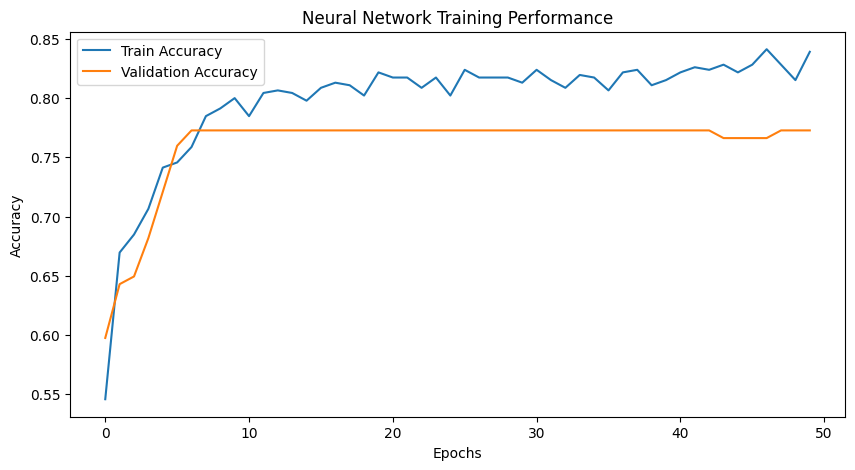

In [59]:
# 🔹 Plot Training Performance
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Neural Network Training Performance')
plt.show()


In [61]:
#model save
import pickle
file=open("model.pkl", 'wb')
pickle.dump(model, file)

**Summary**
* Random Forest classifier accuracy:76.6 %
*Decision Tree classifier accuracy: 72.7%
*Logistic Regression accuracy:72.7%
*Neural Network accuracy:77.27%